In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="red"><b>ch3. 분류분석</b></font>
# 1절. 분류분석 개요
## 1.1 분류분석이란?
- 타겟변수가 categorical인 분석
    * ex. 고객등급예측, 휴면고객예측, 상품구매예측, 보험사기자예측
    * 수업ex. mnist 숫자데이터 분류
- sklearning 패키지 :  예제데이터셋, 전처리,  머신러닝 모형 등 제공

## 1.2 샘플용 데이터셋 접근
### load 계열(패키지 내에 데이터 있음)
    - load_iris(), load_boston(), load_diabetes()...
### fetch 계열(패키지 내에 데이터가 없고, 인터넷 연결시 다운)
    - fetch_openml(), fetch_rov1(로이터뉴스 말뭉치)
### make 계열(가상의 데이터 생성)
    - make_classification() : 분류분석용 데이터 생성
    - make_regression() : 회귀분석용 데이터 생성
    - make_blobs() : 군집분석용 데이터 생성(타겟변수X)

In [2]:
# load 계열(패키지 내에 데이터 있음)
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# mnist data load
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

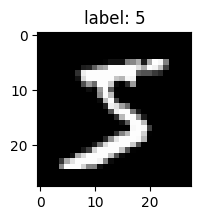

In [9]:
# 1st img print
plt.figure(figsize=(2,2))
plt.imshow(X_train[0], cmap='gray')
plt.title('label: {}'.format(y_train[0]))
plt.show()

In [16]:
# fetch 계열(패키지 내에 데이터가 없고, 인터넷 연결시 다운)
from sklearn.datasets import fetch_openml
# mnist fetct : mnist, iris, boston, fashion mnist
mnist = fetch_openml(name="mnist_784", version=1, as_frame=False, parser='auto')  
# (28*28) =784 이미지를 1차원으로 가져옴, as_frame=False : 데이터프레임으로 가져오지 않겠다 -> 넘파이 배열로 가져옴
X, y = mnist.data, mnist.target.astype('int')
X.shape, y.shape

((70000, 784), (70000,))

In [14]:
X = X.reshape(-1, 28,28)
X.shape

(70000, 28, 28)

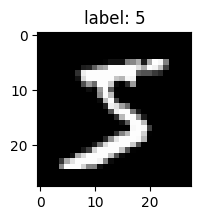

In [17]:
plt.figure(figsize=(2,2))
plt.imshow(X_train[0], cmap='gray')
plt.title('label: {}'.format(y_train[0]))
plt.show()

# 2절. 분류분석의 종류
- predict()
## 2.1 확률적 모형
    - 주어진 데이터에 각 클래스가 정답일 확률을 계산하는 모형
    - predict_proba() : 각 분류 클래스별 확률을 알려줌(일부의 판별함수 모형에 있긴 함)
    - predict_log_proba() : 확률의 로그값을 알려줌   
### 1) 확률적 생성 모형
        - 각 클래스별 특징 데이터 확률분포 추정(베이즈정리를 사용) 소량의 데이터로도 작동
        - ex. QuadraticDiscriminantAnalysis, 나이브 베이지안 
### 2) 확률적 판별 모형
        - 확률을 계산하는 함수 이용
        - ex. 의사결정 나무 , 로지스틱회귀
    
## 2.2 판별함수 모형
    - 주어진 데이터를 클래스에 따라 어떤 영역으로 나눠지는 경계면을 찾는 함수
    - 퍼셉트론, 서포트 벡터 머신, MLP(신경망
    
=> RandomForest, LGBM, XGBoost, CatBoost 등의 앙상블 모형이 더 많이 쓰임

# 3절 분류모형 1. 확률적 생성 모형
- 베이즈 정리를 사용하여 확률분포 계산
## 3.1 QDA
- X가 연속형(실수)이면서 정규분포라고 가정함

In [18]:
# 샘플데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_features=2, # 독립변수 개수
                          n_informative=2, # 타겟변수에 영향을 주는 독립변수의 개수
                           n_redundant=0, # 타겟변수에 영향을 안주는 독립변수의 개수
                           n_clusters_per_class=1, # 클래스 내 서브그룹수
                           n_classes=2, # 타겟변수 클래수 수
                           n_samples=100, # 데이터갯수(행수. 기본값100)
                           random_state=9 # 시드값
                          )
X.shape, y.shape

((100, 2), (100,))

In [20]:
import numpy as np
np.unique(y)  # 타겟변수는 총 2가지 종류

array([0, 1])

In [22]:
np.mean(y) # 타겟변수는 0과 1 뿐이므로 평균을 보면 비율을 알수 있다

0.5

In [23]:
X[y==1].shape # 정확한 개수를 파악할 수 있다

(50, 2)

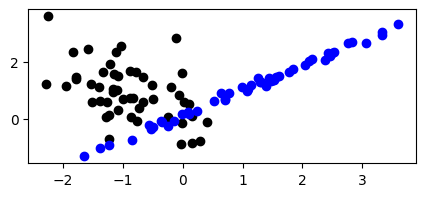

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,2))
plt.scatter(X[y==0,0], X[y==0,1], c='k')
plt.scatter(X[y==1,0], X[y==1,1], c='b')
plt.show()

In [26]:
# (,0) 대칭구조
X[y==1] = -X[y==0]

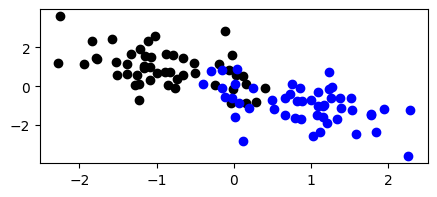

In [27]:
plt.figure(figsize=(5,2))
plt.scatter(X[y==0,0], X[y==0,1], c='k')
plt.scatter(X[y==1,0], X[y==1,1], c='b')
plt.show()

In [29]:
# QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis()
model.fit(X, y)

QuadraticDiscriminantAnalysis()

In [32]:
x= [[5,5]]  # 2차원 데이터 predict
model.predict(x)[0]

1

In [33]:
p = model.predict_proba(x)
print(p) # 0으로 분류될 확률, 1로 분류될 확률

[[8.84215536e-06 9.99991158e-01]]


In [ ]:
model.classes_ # qnsfbehlf sodyd

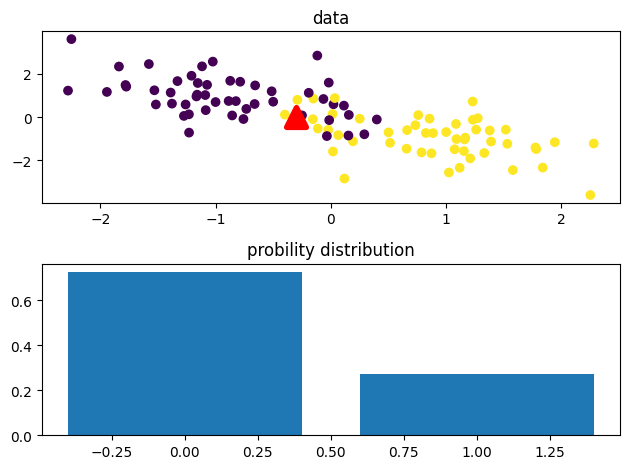

In [41]:
x=[[-0.3,0]]
p=model.predict_proba(x)
plt.subplot(211)  # 2행 1열 그래프 중 첫 번째 그래프 (2,1,1)
plt.scatter(X[:,0], X[:,1], c=y)
plt.scatter(x = x[0][0], y = x[0][1], c='r', s=200, lw=4, marker='^')
plt.title('data')
plt.subplot(212) # 2행 1열 그래프 중 두번째 그래프 (2, 1, 2)
plt.bar(model.classes_, p[0])
plt.title('probility distribution')
plt.tight_layout()
plt.show()

In [37]:
model.predict(x)

array([0])

## 3.2 나이브 베이지안 모형

In [53]:
#데이터
import seaborn as sns
iris = sns.load_dataset('iris')
X = iris.iloc[:,:-1].values
y = iris.iloc[:,-1].values # 범주형(문자) - 라벨인코딩 없이 적용 가능

#모형생성
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X, y)

MultinomialNB()

In [51]:
X.loc[0].values

array([5.1, 3.5, 1.4, 0.2])

In [55]:
test_x = np.array([[5.1,3.5,1.5,0.2]]) # X.loc[0]
test_x = np.array([X[0]])

print('testX pred :', model.predict(test_x))
print(model.classes_)
print(model.predict_proba(test_x))

testX pred : ['setosa']
['setosa' 'versicolor' 'virginica']
[[0.75199536 0.16092948 0.08707516]]


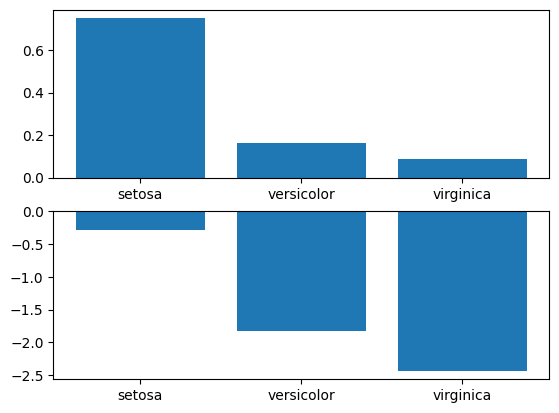

In [57]:
plt.subplot(211)
plt.bar(model.classes_, model.predict_proba(test_x)[0])
plt.subplot(212)
plt.bar(model.classes_, model.predict_log_proba(test_x)[0]) # 로그 확률값
plt.show()

# 4절. 분류모형 2. 확률적 판별모형
## 4.1 로지스틱 회귀분석

In [65]:
# 데이터
X, y = make_classification(n_features=1,  # 독립변수 1개
                          n_redundant=0,  # 종속변수에 영향을 끼치는 독립변수 없음
                          n_informative=1, # 종속변수에 영향을 끼치는 독립변수 1개
                          n_classes=2, # 타겟변수의 클래스 수 (0 아니면 1)
                          n_clusters_per_class=1, 
                          n_samples=100,
                          random_state=1
                          )
X[:3]

array([[-1.65902848],
       [-0.64202884],
       [-1.53918976]])

In [67]:
X.shape, y.shape # X는 독립변수가 1개여도 2차원이다

((100, 1), (100,))

In [68]:
# 모형
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X,y)

In [78]:
import numpy as np
xx = np.linspace(-3, 3, 100)  # -3 ~ 3까지 같은 간격의 데이터 100개 생성
# xx의 행축 (axis=0)
test_x = xx.reshape(-1,1) # reshape 이용 - but 선생님이 없어보인다고 함
test_x = xx[:, np.newaxis]  # 추천
test_x = np.expand_dims(xx, axis=1) # 추천
test_x = xx[:, None]

y_hat = model.predict(test_x)
prob = model.predict_proba(test_x)
prob0 = prob[:, 0]  # 0으로 분류될 확률
prob1 = prob[:, 1] # 1로 분류될 확률

<BarContainer object of 2 artists>

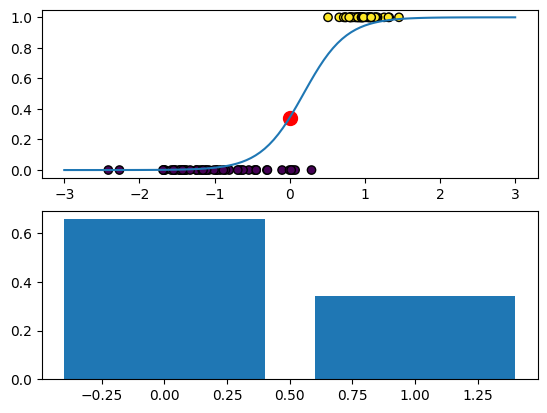

In [79]:
plt.subplot(211)
x = [[0]]
prob_x = model.predict_proba(x)
plt.scatter(X, y, c=y, edgecolors='k')
plt.plot(xx, prob1)
plt.scatter(x[0][0], prob_x[0][1], c='r', s=100)
plt.subplot(212)
plt.bar(model.classes_, prob_x[0])

## 4.2 의사결정 나무
- ★ 종속변수에 영향을 주는 독립변수의 범주를 찾는 목적

In [81]:
from sklearn.datasets import load_iris
data = load_iris()

In [85]:
X = data.data[:,2:]
y = data.target
feature_names = [name[:-5] for name in data.feature_names[2:]]
feature_names

['petal length', 'petal width']

In [87]:
# 모형 생성
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion="entropy", # 분류품질 기준
                                 max_depth=1,
                                 random_state=0)
dt_model.fit(X, y) # depth가 1이라 성능이 좋지 않을 예정

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [88]:
print(X[50])
test_x = [[4.7, 1.4]]
print('예측값 :', dt_model.predict(test_x))
print(dt_model.classes_)
print(dt_model.predict_proba(test_x))

[4.7 1.4]
예측값 : [1]
[0 1 2]
[[0.  0.5 0.5]]


In [91]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:, 2:] # 2번째, 3번째 열만
y = data.target
feature_names = [name[:-5] for name in data.feature_names[2:]]
print(feature_names)

# 모형 생성
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion="entropy", # 분류품질 기준
                                 max_depth=1,
                                 random_state=0)
dt_model.fit(X, y) # depth가 1이라 성능이 좋지 않을 예정

print(X[50])
test_x = [[6.1, 1.9]]
print('예측값 :', dt_model.predict(test_x))
print(dt_model.classes_)
print(dt_model.predict_proba(test_x))

['petal length', 'petal width']
[4.7 1.4]
예측값 : [1]
[0 1 2]
[[0.  0.5 0.5]]


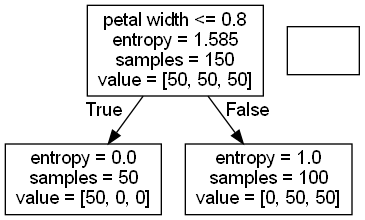

In [92]:
import io
from sklearn.tree import export_graphviz
import pydot
from IPython.core.display import Image

def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)
draw_decision_tree(dt_model, feature_names)

In [94]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = model.predict(
    np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
        c=[cmap(idx)], marker=markers[idx], s=80, label=species[cl])
        plt.xlabel(data.feature_names[2])
        plt.ylabel(data.feature_names[3])
        plt.legend(loc='upper left')
        plt.title(title)
    return Z

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

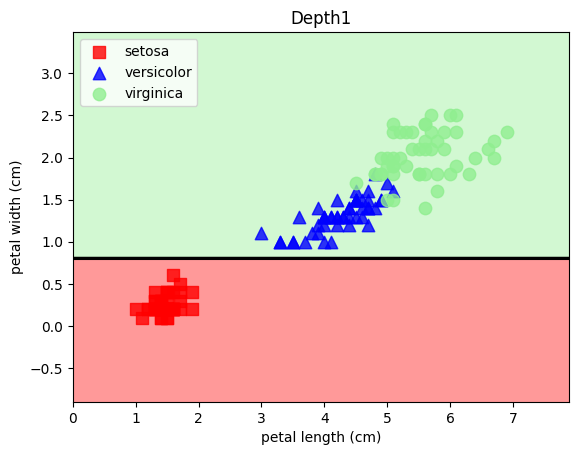

In [95]:
plot_decision_regions(X, y, dt_model, 'Depth1')

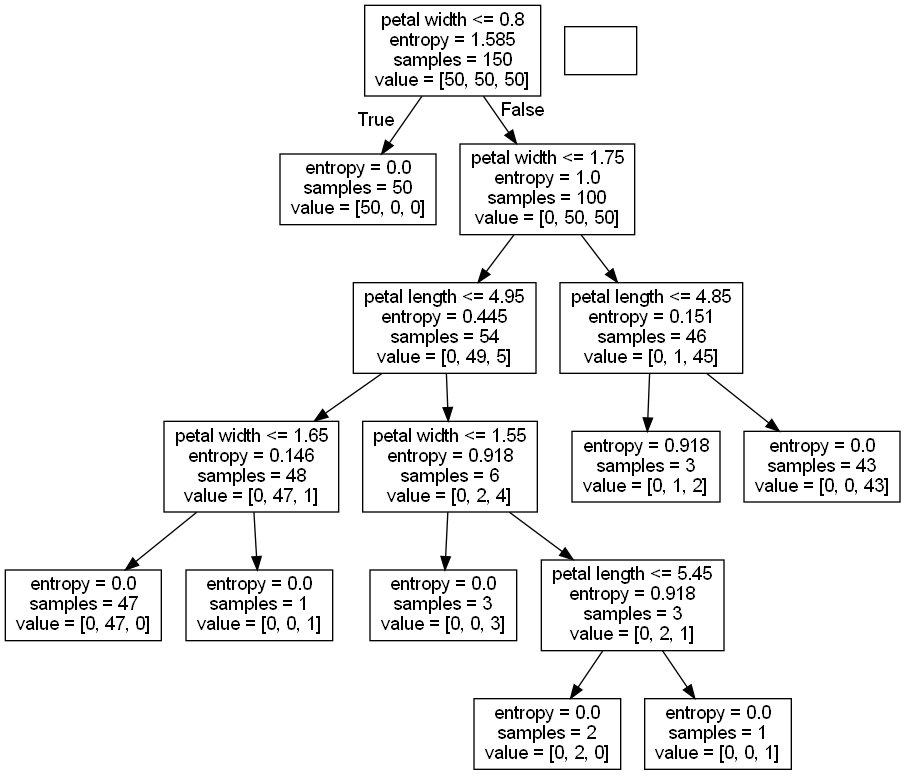

In [99]:
dt_model5 = DecisionTreeClassifier(criterion='entropy',
                                  max_depth=15,
                                  random_state=0)
dt_model5.fit(X,y)
draw_decision_tree(dt_model5, feature_names)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]])

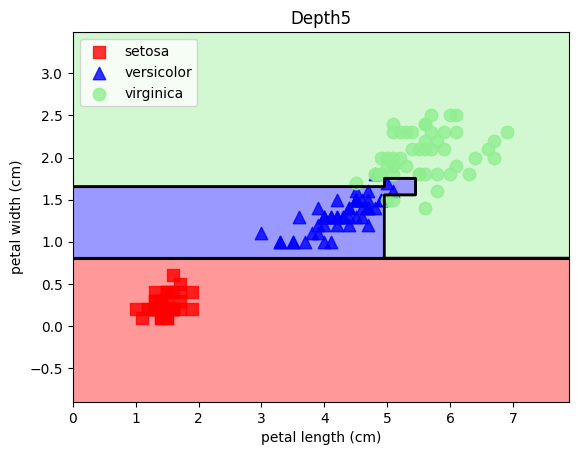

In [100]:
plot_decision_regions(X, y, dt_model5, 'Depth5')

In [101]:
predict = dt_model5.predict(X)
predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# 5절. 분류모형 3. 판별함수 모형
- SVM, 퍼셉트론, MLP(predict_proba() 있음)...
- predict_prob 대신 decision_function() 있음

In [105]:
import pandas as pd
iris = load_iris()
idx = pd.Series(iris.target).isin([0,2])

In [107]:
idx=idx.tolist()

In [110]:
X = iris.data[idx]
y = iris.target[idx]
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [111]:
from sklearn.svm import SVC
model = SVC().fit(X,y)
model

SVC()

In [112]:
y_hat = model.predict(X)
pd.crosstab(y, y_hat)

col_0,0,2
row_0,,
0,50,0
2,0,50


In [128]:
x = [[3.1, 1.5, 1.2, 0.1]]
pred = model.predict(x)
df   = model.decision_function(x)
print('예측값 :', pred)
print('판별함수 결과 :', df)

예측값 : [0]
판별함수 결과 : [-0.659]


## 5.2 퍼셉트론

In [116]:
from sklearn.linear_model import Perceptron
model = Perceptron(max_iter=100, eta0=0.1).fit(X, y)

In [118]:
y_hat = model.predict(X)
pd.crosstab(y, y_hat)

col_0,0,2
row_0,,
0,50,0
2,0,50


In [120]:
x = [[4.6, 3.1, 1.5, 0.2]]
pred = model.predict(x)
df = model.decision_function(x)
print('예측값', pred)
print('판별함수 결과', df)

예측값 [0]
판별함수 결과 [-1.473]


# 5.2 다중퍼셉트론 (인공신경망)
- predict / decision_function / predict_proba / predict_log_proba

In [127]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(50,50,30),
                   max_iter= 500,
                   activation='relu')
mlp.fit(X, y)
y_hat = mlp.predict(X)
pd.crosstab(y, y_hat)

col_0,0,2
row_0,,
0,50,0
2,0,50


# 6절. 분류 모형 성능 평가
- 혼동행렬(교차표)
- score 함수 : accuracy, recall, precision, f1_score, fbeta_score
- ROC 커브 : roc 커브 영역 확인
- 두 모형이 혼동행렬이 같은 경우
##  6.1 혼동행렬(교차표)

In [125]:
y_true = [1,1,0,0,2,1,0,2,2] 
y_pred = [1,1,0,1,1,0,0,2,1]
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true, y_pred)

array([[2, 1, 0],
       [1, 2, 0],
       [0, 2, 1]], dtype=int64)

In [126]:
pd.crosstab(y_true, y_pred, colnames=['예측값'], rownames=['실제값'])

예측값,0,1,2
실제값,,,
0,2,1,0
1,1,2,0
2,0,2,1


In [129]:
result = pd.read_csv('data/model_result.csv')
result

,CUST_ID,y_true,y_pred
0,37,0,0
1,51,0,0
2,60,0,0
3,65,0,0
4,73,0,0
...,...,...,...
1788,22320,0,0
1789,22328,1,0
1790,22329,0,0
1791,22342,0,0


In [131]:
result.isnull().sum(), result.shape

(CUST_ID    0
 y_true     0
 y_pred     0
 dtype: int64,
 (1793, 3))

In [133]:
result['y_true'].value_counts()

0    1635
1     158
Name: y_true, dtype: int64

In [140]:
# 교차표
pd.crosstab(y_true, y_pred, colnames=['예측값'], rownames=['실제값']) # 그룹이 3개 이상일 때

예측값,0,1,2
실제값,,,
0,2,1,0
1,1,2,0
2,0,2,1


## 6.2 혼동행렬을 이용한 평가
- 각종 score() 함수

In [141]:
result = pd.read_csv('data/model_result.csv') # 보험사기자 실제값과 예측값
result.sample(3)

,CUST_ID,y_true,y_pred
1375,17235,0,0
153,1722,0,0
638,7732,0,0


In [142]:
pd.crosstab(result.y_true, 
            result.y_pred,
            margins=True,  # 합계 출력
           colnames=['예측값'],
           rownames=['실제값'])

예측값,0,1,All
실제값,,,
0,1613,22,1635
1,81,77,158
All,1694,99,1793


In [143]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import f1_score, fbeta_score
# 정확도 : 전체중에서 맞게 예측한 확률
accuracy_score(result.y_true, result.y_pred)

0.9425543781372002

In [144]:
# 정밀도(precision) : positive로 예측한 것 중에 맞게 예측한 확률
precision_score(result.y_true, result.y_pred)

0.7777777777777778

In [145]:
# 재현율(recall) : 실제 positive 중 맞게 예측한 확률
recall_score(result.y_true, result.y_pred)

0.4873417721518987

In [146]:
# 특이도(specificity) : 실제 negative 중 맞게 예측한 확률
recall_score(result.y_true, result.y_pred, pos_label=0)

0.9865443425076452

In [ ]:
# 위양성율(fprate) : FN / (TN+FP) ; 실제 negative인데 positive로 예측한 확률
# 함수 없음

In [147]:
# f1 score : recall과 precision 조화평균
f1_score(result.y_true, result.y_pred)

0.5992217898832685

In [148]:
# beta=1 : f1_score - recall과 precision의 비중을 같게
fbeta_score(result.y_true, result.y_pred, beta=1)

0.5992217898832685

In [149]:
# beta=2 : f1_score - recall의 가중치를 높게 precision의 비중을 낮게
fbeta_score(result.y_true, result.y_pred, beta=2)

0.5266757865937073

In [150]:
# beta=0.5 : f1_score - recall의 가중치를 낮게 precision의 비중을 높게
fbeta_score(result.y_true, result.y_pred, beta=0.5)

0.6949458483754513

## 6.3 ROC커브를 이용한 성능 비교
- ROC그래프의 가로축 위양성율(fprate : False Positive rate), 새로축 recall값

In [152]:
X, y = make_classification(weights=[0.95,0.05], # 0 그룹 : 95%, 1그룹 5%
                           n_samples=1000,
                           random_state=5
                          )
X.shape, y.shape

((1000, 20), (1000,))

In [153]:
np.unique(y), y.mean()

(array([0, 1]), 0.057)

In [154]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0).fit(X,y)
model

LogisticRegression(random_state=0)

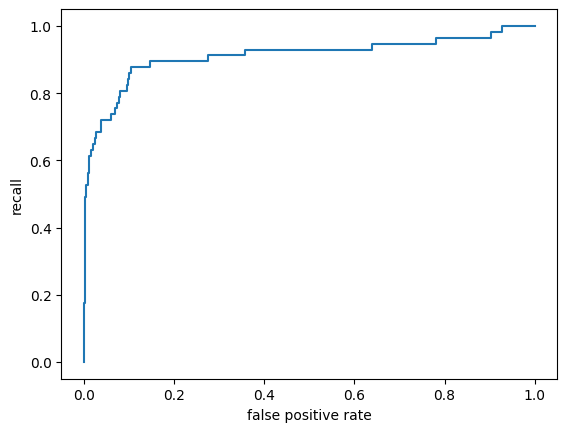

In [155]:
from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve(y, model.decision_function(X))
plt.plot(fpr, tpr)
plt.xlabel('false positive rate')
plt.ylabel('recall')
plt.show()

In [160]:
model.predict_proba(X)

array([[0.99628434, 0.00371566],
       [0.97323269, 0.02676731],
       [0.9750936 , 0.0249064 ],
       ...,
       [0.99715826, 0.00284174],
       [0.99824868, 0.00175132],
       [0.97500581, 0.02499419]])

In [161]:
y_proba

array([3.71566481e-03, 2.67673097e-02, 2.49064049e-02, 5.92630191e-01,
       3.23526224e-03, 9.20883593e-04, 4.39432063e-02, 1.10246879e-02,
       2.72300425e-03, 1.76778864e-03, 7.89100098e-05, 1.35112334e-01,
       5.55605934e-03, 1.71734546e-02, 2.70019346e-04, 9.26655203e-04,
       4.42960620e-03, 5.96140350e-01, 1.85797356e-02, 1.89054667e-02,
       4.91136237e-02, 7.28972306e-03, 9.95394970e-01, 5.59429000e-03,
       1.01704602e-01, 5.06200256e-03, 6.87198227e-04, 5.26143318e-02,
       9.56121325e-03, 2.54416926e-02, 1.56866344e-02, 5.31990315e-02,
       7.50083517e-01, 5.38117420e-05, 9.90340437e-03, 5.78718808e-04,
       9.66589411e-03, 6.44433200e-01, 3.15734727e-02, 1.76199017e-02,
       9.05807997e-01, 6.19951771e-03, 1.46862440e-03, 1.99159587e-02,
       2.13809412e-04, 3.82583051e-05, 1.09280852e-02, 4.18128543e-02,
       3.10220195e-01, 7.55265853e-03, 6.38833340e-01, 2.31996927e-02,
       2.41325185e-02, 4.26240864e-02, 2.49413184e-02, 1.14024688e-03,
      

In [163]:
thr1

array([1.99723348e+00, 9.97233482e-01, 9.16588082e-01, 9.05807997e-01,
       8.03585476e-01, 7.66843588e-01, 5.61219153e-01, 5.48705977e-01,
       4.84433990e-01, 4.66399385e-01, 4.43483468e-01, 4.00516573e-01,
       3.93910950e-01, 3.88345088e-01, 3.74872242e-01, 3.64494922e-01,
       3.62889460e-01, 3.07090368e-01, 2.99673619e-01, 2.64096518e-01,
       2.62911838e-01, 2.58423930e-01, 2.55397026e-01, 1.91759024e-01,
       1.87094165e-01, 1.37910597e-01, 1.35112334e-01, 1.10616936e-01,
       1.10255375e-01, 1.08720097e-01, 1.08708731e-01, 1.01341035e-01,
       9.82300060e-02, 9.61346614e-02, 9.28437922e-02, 8.14049325e-02,
       8.03580786e-02, 7.56418535e-02, 7.54934511e-02, 7.47492873e-02,
       7.15300541e-02, 6.92587484e-02, 6.91376130e-02, 5.26143318e-02,
       5.23896182e-02, 2.50971806e-02, 2.49941866e-02, 1.71734546e-02,
       1.70904447e-02, 5.59255578e-03, 5.56603747e-03, 2.59151903e-03,
       2.57372817e-03, 6.97463584e-04, 6.97281645e-04, 4.89906078e-04,
      

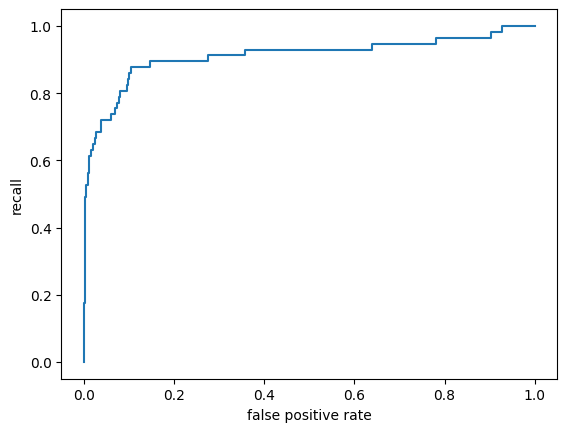

In [159]:
y_proba = model.predict_proba(X)[:,1]
fpr1, tpr1, thr1 = roc_curve(y, y_proba)
plt.plot(fpr1, tpr1)
plt.xlabel('false positive rate')
plt.ylabel('recall')
plt.show()

## 6.4 두 모형의 혼동행렬이 같은 경우(roc_curve 사용) 

In [171]:
X, y = make_classification(weights=[0.95,0.05], # 0 그룹 : 95%, 1그룹 5%
                           n_samples=1000,
                           random_state=5
                          )
X.shape, y.shape

((1000, 20), (1000,))

In [172]:
model1 = LogisticRegression().fit(X,y)
model2 = SVC(gamma=0.0001,  # 작을수록 경계면이 부드러운 곡선
            C=3000,  # 오차허용범위 - ! 커질 수록 과적합이 발생하기 쉽다.
            probability=True).fit(X,y)
y_hat1 = model1.predict(X)
y_hat2 = model2.predict(X)

In [167]:
display(pd.crosstab(y, y_hat1))
display(pd.crosstab(y, y_hat2))
# 두 모형의 혼동행렬이 똑같다. 

col_0,0,1
row_0,,
0,940,3
1,30,27


col_0,0,1
row_0,,
0,940,3
1,30,27


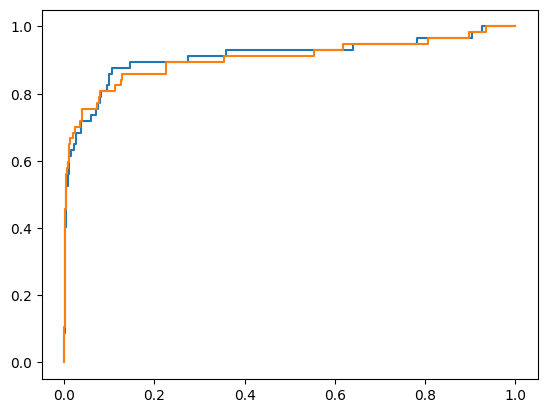

In [173]:
fpr1, tpr1, thr1 = roc_curve(y, model1.decision_function(X))
fpr2, tpr2, thr2 = roc_curve(y, model2.decision_function(X))
plt.plot(fpr1, tpr1)
plt.plot(fpr2, tpr2)
plt.show()

In [174]:
# AUC(Area Under Curve) : roc커브 아랫부분의 영역(넓이)
# AUC = 1 : 완벽한 모델
# AUC < 0.5 : 최악의 모델
# AUC = 0,5 : 동전던지기와 일치
from sklearn.metrics import auc
auc(fpr1, tpr1), auc(fpr2, tpr2)

(0.9112202563673234, 0.9037227214377407)

# 연습문제(p.65)

In [176]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
